# Chapter-03. Tensor的计算

## 【章节目标】

- 掌握tensor的基本运算和广播机制
- 掌握tensor的矩阵乘法运算
- 掌握tensor的常见函数运算
- 掌握tensor的排序
- 掌握tensor的统计运算

## 【章节内容】
### 3.1 基本运算
#### 1）算术运算
- torch.add(a,b)：a+b 也可以这样写a.add(b)
- torch.sub(a,b)：a-b
- torch.mul(a,b)：a*b
- torch.div(a,b)：a/b 小数除法，结果保留小数
- torch.fmod(a,b)：a%b 取余
- a//b 整除，结果只保留整数部分
- torch.pow(a,b)：a**b 幂运算

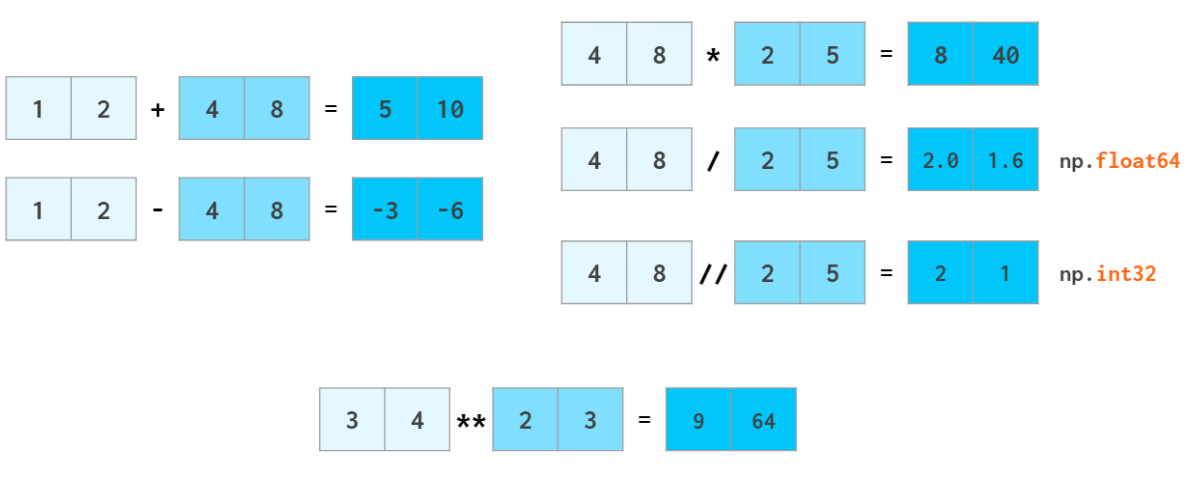

代码演示：

In [1]:
import torch
a = torch.Tensor([1, 2])
b = torch.Tensor([3, 4])
a + b, a.add(b), torch.add(a, b)

(tensor([4., 6.]), tensor([4., 6.]), tensor([4., 6.]))

In [3]:
torch.sub(a, b), a - b

(tensor([-2., -2.]), tensor([-2., -2.]))

In [4]:
torch.mul(a, b), a * b

(tensor([3., 8.]), tensor([3., 8.]))

In [5]:
torch.div(a, b), a / b

(tensor([0.3333, 0.5000]), tensor([0.3333, 0.5000]))

In [6]:
torch.fmod(a, b), a % b

(tensor([1., 2.]), tensor([1., 2.]))

In [7]:
a // b

tensor([0., 0.])

In [8]:
torch.pow(a, b), a ** b

(tensor([ 1., 16.]), tensor([ 1., 16.]))

#### 2） 常见函数运算
- 幂运算：torch.pow(a,b),a.pow(b)
- 指数运算:torch.exp(a),a.exp()
- 对数运算:torch.log(a),a.log()
- 开根号:torch.sqrt(a),a.sqrt()
- 正弦：torch.sin(a),a.sin()
- 余弦：torch.cos(a),a.cos()

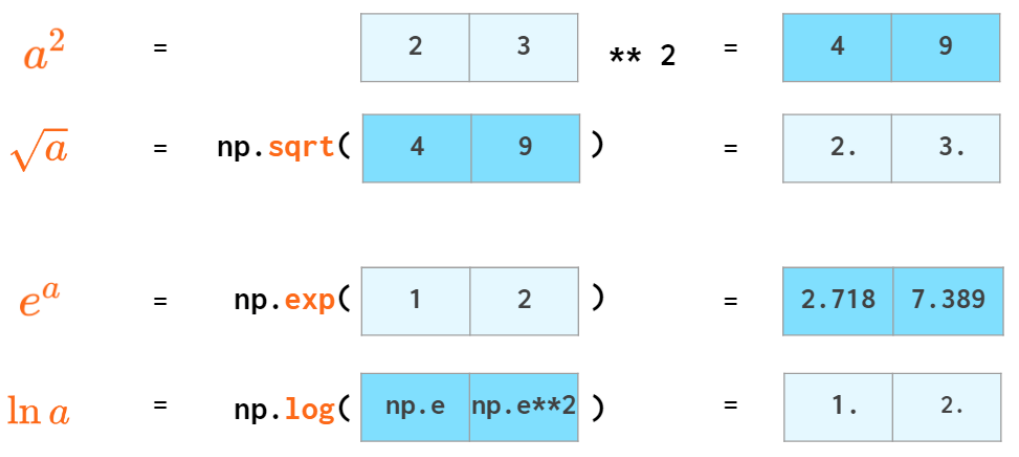

In [9]:
a = torch.Tensor([4, 9])
b = torch.Tensor([1, 2])
a.pow(b), torch.pow(a, b)

(tensor([ 4., 81.]), tensor([ 4., 81.]))

In [10]:
torch.exp(b), b.exp()

(tensor([2.7183, 7.3891]), tensor([2.7183, 7.3891]))

In [11]:
torch.log(a), a.log()

(tensor([1.3863, 2.1972]), tensor([1.3863, 2.1972]))

In [12]:
torch.sqrt(a), a.sqrt()

(tensor([2., 3.]), tensor([2., 3.]))

In [13]:
torch.sin(a), a.sin()

(tensor([-0.7568,  0.4121]), tensor([-0.7568,  0.4121]))

#### 3） 取整函数
- 向下取整数：torch.floor(a),a.floor()
- 向上取整数：torch.ceil(a)
- 四舍五入：torch.round(a)
- 裁剪，只取整数部分：torch.trunc(a)
- 只取小数部分：torch.frac(a)
- 梯度裁剪：torch.clamp(a,min,max) 对于a中低于min的全变成min,且对于高于max的全变成max

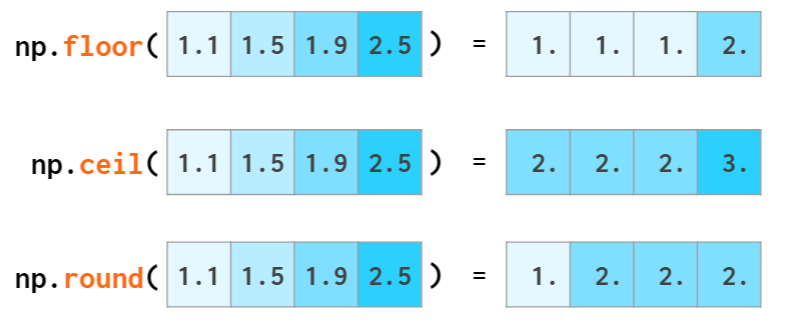

In [14]:
a = torch.Tensor([-4.3, 9.6])
torch.floor(a), a.floor()

(tensor([-5.,  9.]), tensor([-5.,  9.]))

In [15]:
torch.ceil(a), a.ceil()

(tensor([-4., 10.]), tensor([-4., 10.]))

In [16]:
torch.round(a), a.round()

(tensor([-4., 10.]), tensor([-4., 10.]))

In [20]:
torch.trunc(a), a.trunc()

(tensor([-4.,  9.]), tensor([-4.,  9.]))

In [21]:
torch.frac(a), a.frac()

(tensor([-0.3000,  0.6000]), tensor([-0.3000,  0.6000]))

In [23]:
torch.clamp(a, -2, 2), a.clamp(-2, 2) # 限制在[-2,2]

(tensor([-2.,  2.]), tensor([-2.,  2.]))

#### 4）Pytorch中的in-place操作
- “就地”操作，即不允许使用临时变量。也称为原味操作。
- 相当于a=a+b
- add_、sub_、mul_等等

In [24]:
a = torch.Tensor([1, 2])
b = torch.Tensor([3, 4])
a.add(b)
a+b
a  # a的值没有改变  必须写 a=a+b  a=a.add(b)

tensor([1., 2.])

In [25]:
a.add_(b)
a # a的值发生了改变，相当于a=a+b（直接这样更直观）

tensor([4., 6.])

#### 5） Pytorch中的广播机制
- 广播机制：张量shape可以自动扩展为相同大小
- A.ndim == B.ndim：
    - 同一dim上length相等
    - 同一dim上length有一个为1（1自动扩展到跟另一tensor相同dim的length相等）
    - 简单说：为1的一方复制到等于不为1的一方
- A.ndim ！= B.ndim时怎么办？
    - 右对齐法则（会在ndim小的tensor左侧添加dim来保证A.ndim == B.ndim）

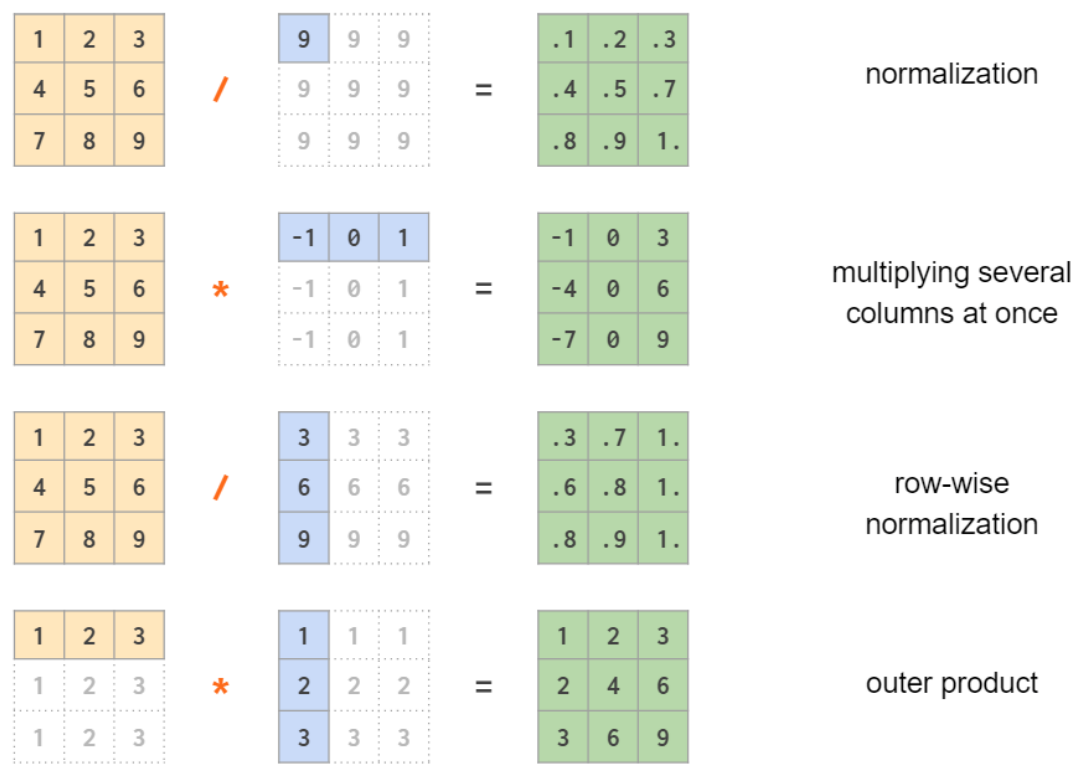

In [26]:
a = torch.arange(1, 10).reshape(3, 3).to(torch.float32) # 不转换为小数的话结果为整除
a / 9

tensor([[0.1111, 0.2222, 0.3333],
        [0.4444, 0.5556, 0.6667],
        [0.7778, 0.8889, 1.0000]])

In [27]:
b = torch.Tensor([-1, 0, 1])
a.shape, b.shape, a * b

(torch.Size([3, 3]),
 torch.Size([3]),
 tensor([[-1.,  0.,  3.],
         [-4.,  0.,  6.],
         [-7.,  0.,  9.]]))

In [28]:
b = torch.Tensor([3, 6, 9]).reshape(3, 1)
a / b

tensor([[0.3333, 0.6667, 1.0000],
        [0.6667, 0.8333, 1.0000],
        [0.7778, 0.8889, 1.0000]])

In [29]:
a = torch.Tensor([1, 2, 3])
b = torch.Tensor([1, 2, 3]).reshape(3, 1)
a.shape, b.shape

(torch.Size([3]), torch.Size([3, 1]))

In [30]:
a * b

tensor([[1., 2., 3.],
        [2., 4., 6.],
        [3., 6., 9.]])

In [31]:
a = torch.arange(1, 25).reshape(2, 3, 4) # (2, 3, 4)
b = torch.Tensor([1, 2, 3, 4]) # (4, ) -- (1, 1, 4)
c = b.repeat(2, 3, 1)
d = torch.Tensor([1, 2, 3]).repeat(2, 1)
a, b, c, d

(tensor([[[ 1,  2,  3,  4],
          [ 5,  6,  7,  8],
          [ 9, 10, 11, 12]],
 
         [[13, 14, 15, 16],
          [17, 18, 19, 20],
          [21, 22, 23, 24]]]),
 tensor([1., 2., 3., 4.]),
 tensor([[[1., 2., 3., 4.],
          [1., 2., 3., 4.],
          [1., 2., 3., 4.]],
 
         [[1., 2., 3., 4.],
          [1., 2., 3., 4.],
          [1., 2., 3., 4.]]]),
 tensor([[1., 2., 3.],
         [1., 2., 3.]]))

In [32]:
a + b

tensor([[[ 2.,  4.,  6.,  8.],
         [ 6.,  8., 10., 12.],
         [10., 12., 14., 16.]],

        [[14., 16., 18., 20.],
         [18., 20., 22., 24.],
         [22., 24., 26., 28.]]])

#### 6）矩阵乘法  

对于高维矩阵，@与matmul会计算最后两维的乘法，前面的不进行改变。如果前面的值不对应会使用brodcasting进行补全

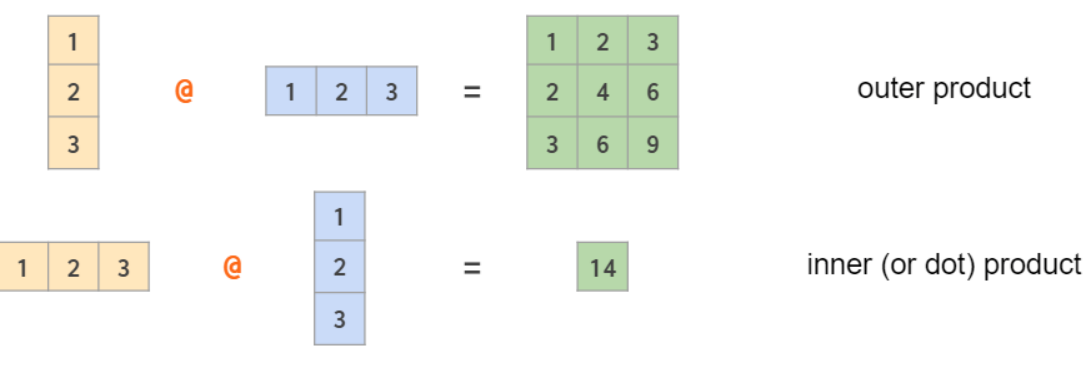

In [33]:
a = torch.Tensor([1, 2, 3]).reshape(3, 1)
b = torch.Tensor([1, 2, 3]).reshape(1, 3)
a @ b

tensor([[1., 2., 3.],
        [2., 4., 6.],
        [3., 6., 9.]])

In [34]:
b @ a, torch.matmul(b, a), b.matmul(a)

(tensor([[14.]]), tensor([[14.]]), tensor([[14.]]))

In [35]:
# 高纬Tensor矩阵乘法
a = torch.arange(1, 13).reshape(2, 2, 3)
b = torch.arange(1, 7).reshape(3, 2) #（3，2）--》（1，3，2）-repeat-》（2，3，2）
a, b, a.matmul(b) # b复制成(2,3,2),然后再后两维进行点积计算

(tensor([[[ 1,  2,  3],
          [ 4,  5,  6]],
 
         [[ 7,  8,  9],
          [10, 11, 12]]]),
 tensor([[1, 2],
         [3, 4],
         [5, 6]]),
 tensor([[[ 22,  28],
          [ 49,  64]],
 
         [[ 76, 100],
          [103, 136]]]))

### 3.2 排序
#### 1）比较运算
- torch.eq(input,other,out=None) ：按成员进行等式操作，相同返回True→Tensor
- torch.equal(tensor1,tensor2) ：如果tensor1和tensor2有相同的size和elements，则为True→ bool
- torch.ge(input,other,out=None) ：input>=other,逐个元素比较输入张量input是否大于或等于另外的张量或浮点数other。若大于或等于则返回为True，否则返回False。若张量other无法自动扩展成与输入张量input相同尺寸，则返回为False。→Tensor
- torch.gt(input,other,out=None) ：input>other→Tensor
- torch.le(input,other,out=None) ：input<=other→Tensor
- torch.lt(input,other,out=None) ：input<other→Tensor
- torch.ne(input,other,out=None) ：input!=other不等于→Tensor

In [36]:
a = torch.Tensor([1, 2, 3])
b = torch.Tensor([1, 2, 3])
torch.eq(a, b), torch.equal(a, b), a.eq(b)

(tensor([True, True, True]), True, tensor([True, True, True]))

In [37]:
b = torch.Tensor([4, 2, 1])
torch.ge(a, b), torch.gt(a, b), torch.le(a, b), torch.lt(a, b), torch.ne(a, b)

(tensor([False,  True,  True]),
 tensor([False, False,  True]),
 tensor([ True,  True, False]),
 tensor([ True, False, False]),
 tensor([ True, False,  True]))

In [38]:
a > b

tensor([False, False,  True])

#### 2）排序运算
- torch.sort(input,dim=1,descending=False)：对目标input沿着指定维度排序；维度，对于二维数据：dim=0 按列排序，dim=1 按行排序，默认 dim=1
- torch.argsort(input,dim=1,descending=False)：返回排序后的元素下标

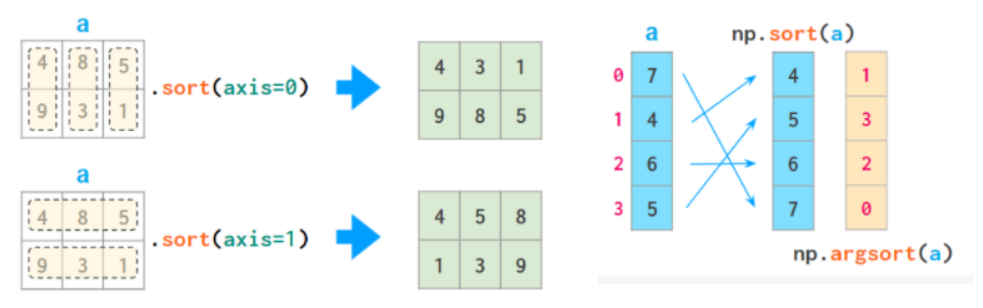

In [39]:
a = torch.randint(1, 10, [2, 3])
a

tensor([[9, 1, 4],
        [1, 9, 8]])

In [40]:
torch.sort(a), a.sort(dim = 0)

(torch.return_types.sort(
 values=tensor([[1, 4, 9],
         [1, 8, 9]]),
 indices=tensor([[1, 2, 0],
         [0, 2, 1]])),
 torch.return_types.sort(
 values=tensor([[1, 1, 4],
         [9, 9, 8]]),
 indices=tensor([[1, 0, 0],
         [0, 1, 1]])))

In [43]:
values, indices = a.sort(dim = 0) 
values, indices

(tensor([[1, 1, 4],
         [9, 9, 8]]),
 tensor([[1, 0, 0],
         [0, 1, 1]]))

In [42]:
torch.argsort(a), torch.sort(a).indices

(tensor([[1, 2, 0],
         [0, 2, 1]]),
 tensor([[1, 2, 0],
         [0, 2, 1]]))

#### 3）部分排序
- torch.topk(input,k,dim=1,)：沿着指定维度返回最大k个数值及其索引值
- torch.kthvalue(input,k,dim=1)：沿着指定维度返回第k个最小值及其索引值

In [44]:
a = torch.randint(1, 10, [2, 3])
a

tensor([[1, 7, 6],
        [6, 3, 4]])

In [45]:
torch.topk(a, k = 2), torch.kthvalue(a, k = 2)

(torch.return_types.topk(
 values=tensor([[7, 6],
         [6, 4]]),
 indices=tensor([[1, 2],
         [0, 2]])),
 torch.return_types.kthvalue(
 values=tensor([6, 4]),
 indices=tensor([2, 2])))

### 3.3 统计运算
#### 1）最大值和最小值
- torch.max(a,dim=)：返回指定轴向的最大值
- torch.min(a)：返回指定轴向的最小值
- torch.argmax(a)：返回指定轴向上最大值的索引
- torch.argmin(a)：返回指定轴向上最小值的索引  
**注意：默认是没有轴向的，即为全局计算**  
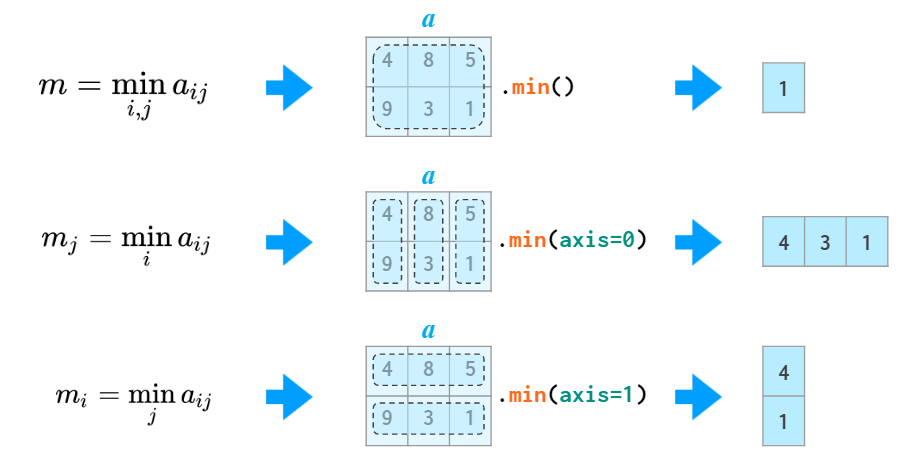  
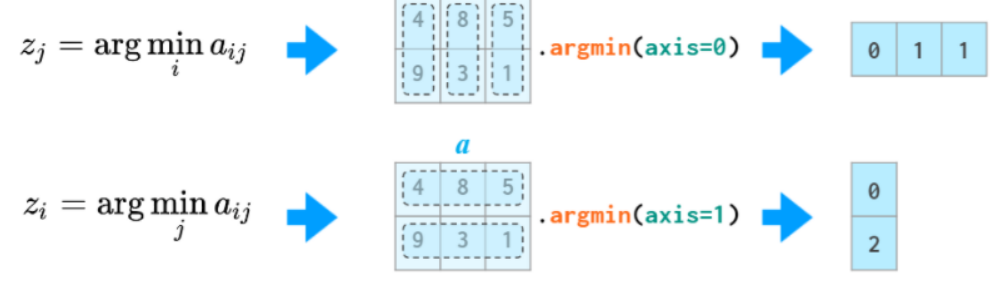

In [46]:
a = torch.randint(1, 10, [2, 3])
a

tensor([[8, 4, 3],
        [4, 1, 1]])

In [47]:
torch.max(a), torch.max(a, dim = 1)

(tensor(8),
 torch.return_types.max(
 values=tensor([8, 4]),
 indices=tensor([0, 0])))

In [48]:
torch.argmax(a), torch.argmax(a, dim = 1) #同时有多个最大值存在时，返回下标较大的下标

(tensor(0), tensor([0, 0]))

#### 2）其他统计函数
- torch.mean(a)：返回平均值
- torch.sum(a)：返回总和
- torch.prod(a)：返回所有元素的积
- torch.std(a)：返回标准差
- torch.var(a)：返回方差
- torch.median(a)：返回中位数
- torch.mode(a)：返回众数
- torch.bincount(a)：返回每个值的频数

In [49]:
a = torch.randint(1, 10, [2, 3]).to(torch.float32) # 小数才可以计算平均值
a

tensor([[1., 7., 7.],
        [3., 7., 8.]])

In [50]:
torch.mean(a), torch.mean(a, dim = 1)

(tensor(5.5000), tensor([5., 6.]))

In [51]:
torch.sum(a, dim = 1), torch.prod(a, dim = 1), torch.std(a, dim = 1), torch.median(a, dim = 1)

(tensor([15., 18.]),
 tensor([ 49., 168.]),
 tensor([3.4641, 2.6458]),
 torch.return_types.median(
 values=tensor([7., 7.]),
 indices=tensor([1, 1])))

In [52]:
torch.bincount(a)

NotImplementedError: "bincount_cpu" not implemented for 'Float'